In [2]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
import numpy as np
import plotly.io as pio
pio.renderers.default = "vscode"

sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.
Hence, we developped a function that automatically defines the mask, iterate over itrace time slices to compute their variograms, then aggregate them and save the results. 

This workflow is can be run using the script ```variogram_parameters_scan```, where all parameters can be set and looped on.
The results will automatically be saved in output folders (see logs when running).

> The original detailed workflow used before implementing the parameters scan is available in the section below

This notebook can still be useful to visualize the trend fitting results (metrics)

### Detailed workflow 

[ now superseded by script binvariogram_parameters_scan ]

In [8]:
params = {'trend': 'multiple_linear_latabs_latReLU_ele_D',
          'trend_before_mask': True,
          'maxlag': 1.2e7,
          'nlags': 20,
          'centers': None,
          'tolerance' : 22.5,
          'mask radius [km]': 75,
          'res [months]': 12*1000,
          'Itrace simulation spec' : {'time':'20kyrBP',},
          'regions':None,
          'const_coords':True
          }
data_cols = {'lat':'lat',
             'lon':'lon',
             'quantity':'d18Op'}

fp_itrace = f"../output/variograms/itrace/sim{params['Itrace simulation spec']['time']}/res{params['res [months]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp_itrace) :
    os.makedirs(fp_itrace)

fp_sisal = f"../output/variograms/sisal/res{params['res [months]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp_sisal) :
    os.makedirs(fp_sisal)

verbose =  False

#### Mask iTrace data around SISAL points

In [ ]:
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [months]']/12),regions=params['regions'],verbose=verbose)

itrace_df = gutils.get_preprocessed_itrace_data(
    data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
    res=params['res [months]'],P=True,format='df',verbose=False,
    sim_prefix = 'b.e13.Bi1850C5.f19_g16',
    sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
    sim_forcings='ice_ghg_orb_wtr',
    sim_kyr= 19,
    sim_num='01',
    sim_model='clm2.h0',
    ) # pd df

loading sisal data
sisal dataframe is ready
loading itrace files
done


In [10]:
itrace_masked_df,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df,params['mask radius [km]'],verbose=True) # type:ignore

> computing distances between data points and anchor points
> done


In [ ]:
fig = putils.plot_global_map(data=itrace_masked_df,
                    quantity_col=data_cols['quantity'],
                    title = 'masked itrace data',
                    quantity=data_cols['quantity'],
                    unit='per mil (VSMOW)',
                    proj=False,
                    symbol='square',
                    size=10,
                    lat_col=data_cols['lat'],
                    lon_col=data_cols['lon'])

# fig.write_html("map.html", auto_open=True)
fig.show()

#### iTrace variograms

In [ ]:
for azimuth in [None] : #None,0,45,90,135
    print(f'computation dir={azimuth}')
    params['direction']=azimuth
    gutils.iterate_and_aggregate_variograms(data_ds = itrace_data, #type:ignore
                                        fp=fp_itrace,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = sisal_df, # type:ignore
                                        verbose = verbose
                                       )

In [ ]:
dict_dfs= {
           'i_all': {'df': pd.read_csv(fp_itrace+'vario_df.csv')},
        #    'i_0': {'df': pd.read_csv(fp_itrace+'d0vario_df.csv')},
        #    'i_45': {'df': pd.read_csv(fp_itrace+'d45vario_df.csv')},
        #    'i_90': {'df': pd.read_csv(fp_itrace+'d90vario_df.csv')},
        #    'i_135': {'df': pd.read_csv(fp_itrace+'d135vario_df.csv')}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bin_edges=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

In [ ]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(bin_edges=np.asarray(dict_dfs['i_all']['df']['lag'].values),
                                          gamma=np.asarray(dict_dfs['i_all']['df']['gamma'].values),
                                          title='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=np.asarray(dict_dfs['i_all']['df']['count']),
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name=fp_itrace+'fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

In [ ]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(bin_edges=np.asarray(dict_dfs[key]['df']['lag'].values),
                                                            gamma=np.asarray(dict_dfs[key]['df']['gamma'].values),
                                                            title='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=np.asarray(dict_dfs[key]['df']['count'].values),
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r :.2e} m')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

#### SISAL variograms

In [ ]:
sisal_df_valid = sisal_df.loc[(sisal_df['binned_age']>=19000)&(sisal_df['binned_age']<20000),['binned_age','lat','lon','site_id','d18Op_VSMOW_exactconv']].copy() #type:ignore

In [ ]:
putils.plot_global_map(data=sisal_df_valid[sisal_df_valid['binned_age']==19000], #type:ignore
                       lon_col='lon',
                       lat_col='lat',   
                       quantity_col='d18Op_VSMOW_exactconv',
                       unit='per mil (VSMOW)',
                       proj=True,
                       title='SISAL 19-20 kyr BP'
                       )

In [ ]:
params['direction']=None
params['const_coords']=False
gutils.iterate_and_aggregate_variograms(data = sisal_df_valid.rename(columns={'d18Op_VSMOW_exactconv':'d18Op','binned_age':'time'}), #type:ignore
                                        fp=fp_sisal,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = None, # type:ignore
                                        verbose = False
                                       )

### Variography results  

In [ ]:
# First, we open the output files of the variogram computations (iTraCE)

with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

list_df =[]
list_metrics = []
list_vario = []
list_vario_sisal=[]

res = 2400 # months
for yrBP in itrace_sims.keys():
    if yrBP != '_comment':
        folder_exp = f'../output/variograms/2026-02-24_sisal_vs_itrace/'
        fp = f'{folder_exp}itrace/sim{yrBP}kyrBP/res{res}/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/' ### PUT PATH HERE 
        fp_sisal = f'{folder_exp}sisal/slice{yrBP}kyrBP/res{res}/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/' ### PUT PATH HERE 
        
        with open(fp+'trend_metricsNone.json', 'r') as f: # 'None' refers to the (un)directionality of the variogram ('azimuth' in parameters scan)
            results_dict = json.load(f)
        for i,t in enumerate(list(results_dict.keys())):
            t_yrBP = utils.get_yrBP_from_itrace_time(int(float(t)),start_year=int(yrBP)*1000)
            df, metrics = gutils.multiple_linear_result_dict_to_df(results_dict[t])
            metrics['time']= t_yrBP
            df['time']= t_yrBP
            df['r2']=results_dict[t]['r2']
            df['r2adj']=results_dict[t]['adj_r2']
            df['mae']=results_dict[t]['mae']
            list_df.append(df)
            list_metrics.append(metrics)
            # Load vario SISAL
            with open(f'{fp_sisal}variogram_params_None_t{int(t_yrBP)-res//12}.json', 'r') as f:
                vario_params_sisal = json.load(f)
            vario_params_sisal['time']=  t_yrBP
            list_vario_sisal.append(pd.DataFrame([vario_params_sisal]))
            # Load vario iTraCE
            with open(f'{fp}variogram_params_None_t{int(float(t))}.json', 'r') as f:
                vario_params = json.load(f)
            vario_params['time']=  t_yrBP
            list_vario.append(pd.DataFrame([vario_params]))
result_df = pd.concat(list_df).reset_index(drop=True)
metrics_df = pd.concat(list_metrics).reset_index(drop=True)
vario_df = pd.concat(list_vario).reset_index(drop=True)
vario_sisal_df = pd.concat(list_vario_sisal).reset_index(drop=True)

dict_keys(['11000', '11200', '11400', '11600', '11800'])
dict_keys(['12000', '12200', '12400', '12600', '12800'])
dict_keys(['13000', '13200', '13400', '13600', '13800'])
dict_keys(['14000', '14200', '14400', '14600', '14800'])
dict_keys(['15000', '15200', '15400', '15600', '15800'])
dict_keys(['16000', '16200', '16400', '16600', '16800'])
dict_keys(['17000', '17200', '17400', '17600', '17800'])
dict_keys(['18000', '18200', '18400', '18600', '18800'])
dict_keys(['19000', '19200', '19400', '19600', '19800'])


#### Investigation of trend models coefficients and metrics

In [9]:
print('Mean MAE :',np.mean(result_df['mae']))
print('Mean r2 :',np.mean(result_df['r2']))
print('Mean r2adj :',np.mean(result_df['r2adj']))
print('std MAE :',np.std(result_df['mae']))
print('std r2 :',np.std(result_df['r2']))
print('std r2adj :',np.std(result_df['r2adj']))

Mean MAE : 2.077257781785359
Mean r2 : 0.5053945382227515
Mean r2adj : 0.4681562779264007
std MAE : 0.22288583610413643
std r2 : 0.04274047031025488
std r2adj : 0.046119046539105854


In [ ]:
metrics_df.loc[metrics_df['name']=='D','vif'].mean()


<Figure size 600x500 with 0 Axes>

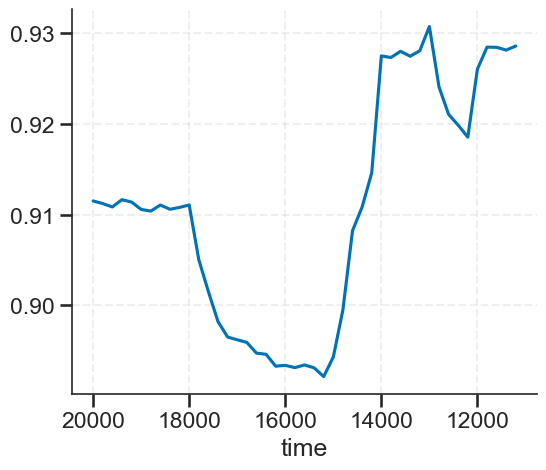

In [12]:
fig,ax = plt.subplots(figsize=(6,5))
result_df.groupby('time')['r2adj'].mean().plot(ax=ax)
sns.despine()
plt.grid(linestyle='--',alpha=0.3)
ax.invert_xaxis()
plt.show()
# plt.scatter(result_df['time'],result_df['r2adj'])

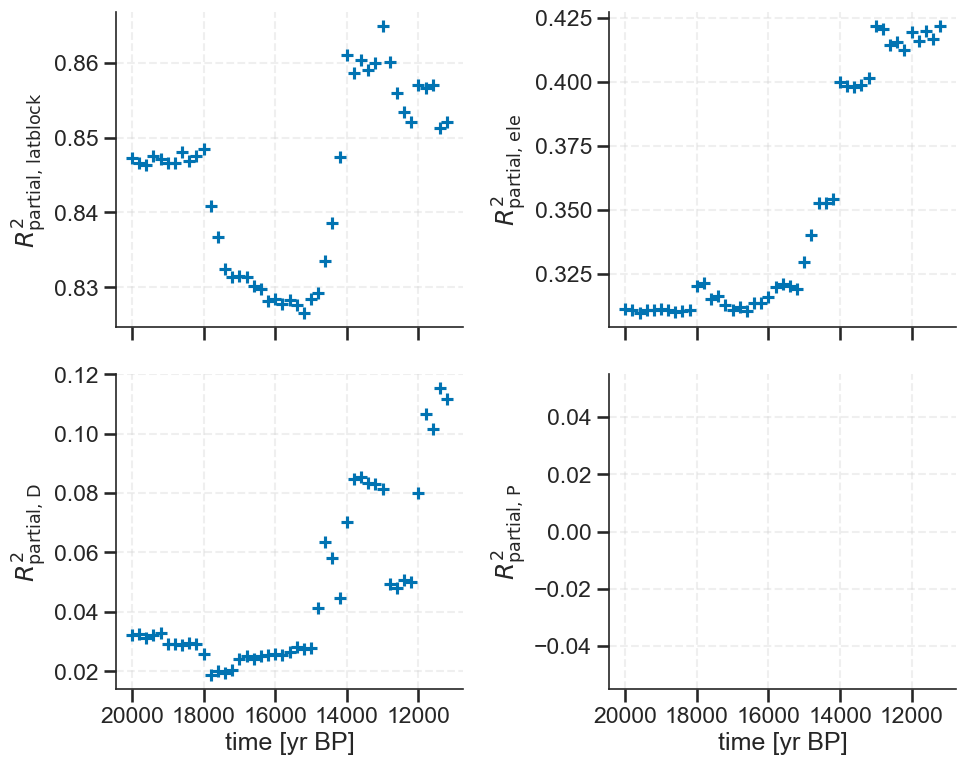

In [7]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['latblock','ele','D','P']):
    ax = axes[i//2,i%2]
    ax.scatter(metrics_df.loc[metrics_df.name==pred,'time'].values,metrics_df.loc[metrics_df.name==pred,'partial r2'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$R^2_\text{{partial, {pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


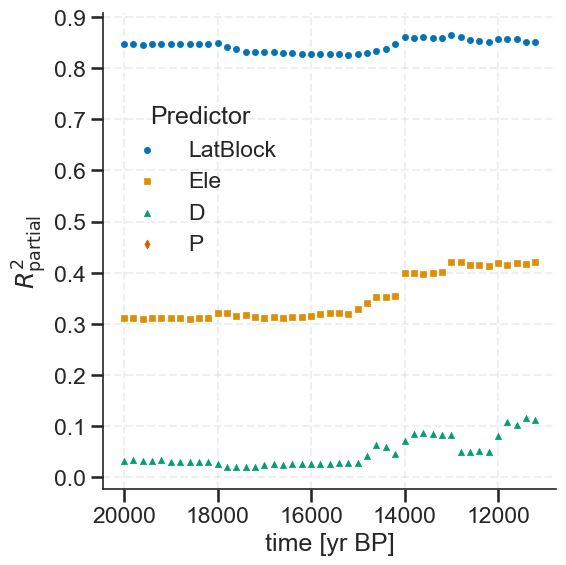

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
preds = ['latblock','ele','D','P']
preds_name = ['LatBlock','Ele','D','P']
colors = sns.color_palette("colorblind", n_colors=len(preds))
markers = ['o','s','^','d']

for p, c, m in zip(preds, colors, markers):
    sub = metrics_df.loc[metrics_df.name == p]
    ax.scatter(sub['time'].values, sub['partial r2'].values, label=preds_name[preds.index(p)], color=c, marker=m, s=20,linewidths=0.5)

ax.set_ylabel(r'$R^2_{\mathrm{partial}}$')
ax.set_xlabel('time [yr BP]')
ax.grid(which='both',linestyle='--', alpha=0.3)
ax.locator_params(axis='y', nbins=10)
ax.invert_xaxis()
ax.legend(title='Predictor', loc='center left', bbox_to_anchor=(0, 0.65), frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors_singleax.png', dpi=300)
plt.show()

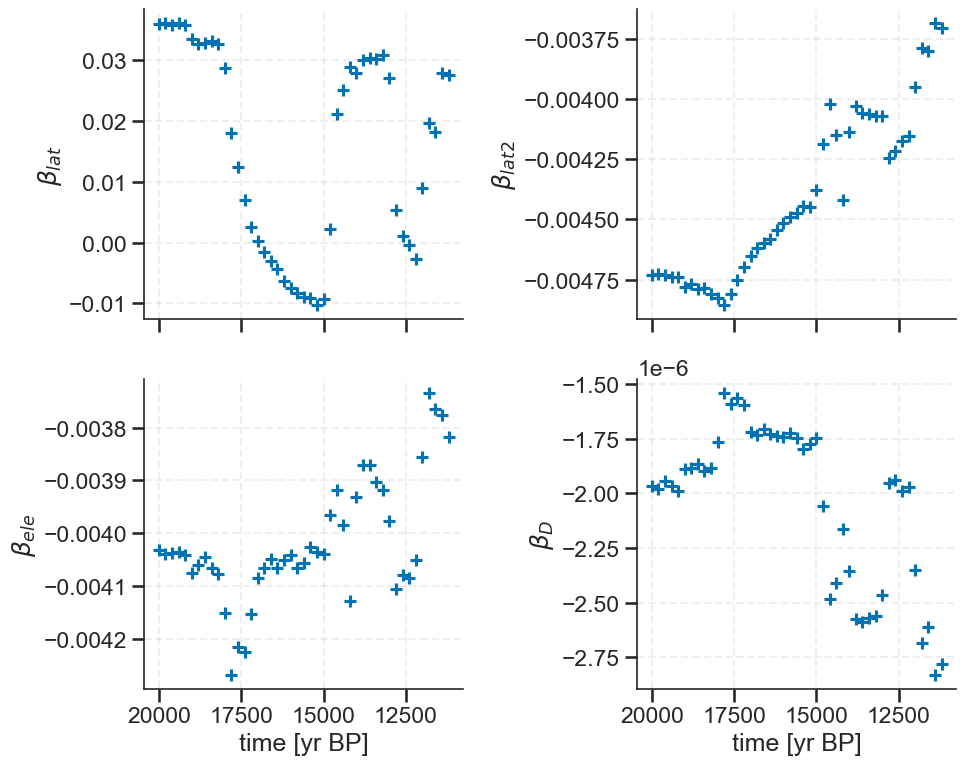

In [4]:
fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
for i,pred in enumerate(['lat','lat2','ele','D']):
    ax = axes[i//2,i%2]
    ax.scatter(result_df.loc[result_df.name==pred,'time'].values,result_df.loc[result_df.name==pred,'beta'].values,marker='+',label=pred)
    ax.set_ylabel(rf'$\beta_{{{pred}}}$')
    ax.grid(linestyle='--',alpha=0.3)

axes[1,1].set_xlabel('time [yr BP]')
axes[1,0].set_xlabel('time [yr BP]')
sns.despine()
axes[0,0].invert_xaxis()

plt.tight_layout()
# plt.savefig('../output/trendmodel_partial_r2_allpredictors.png',dpi=500)
plt.show()


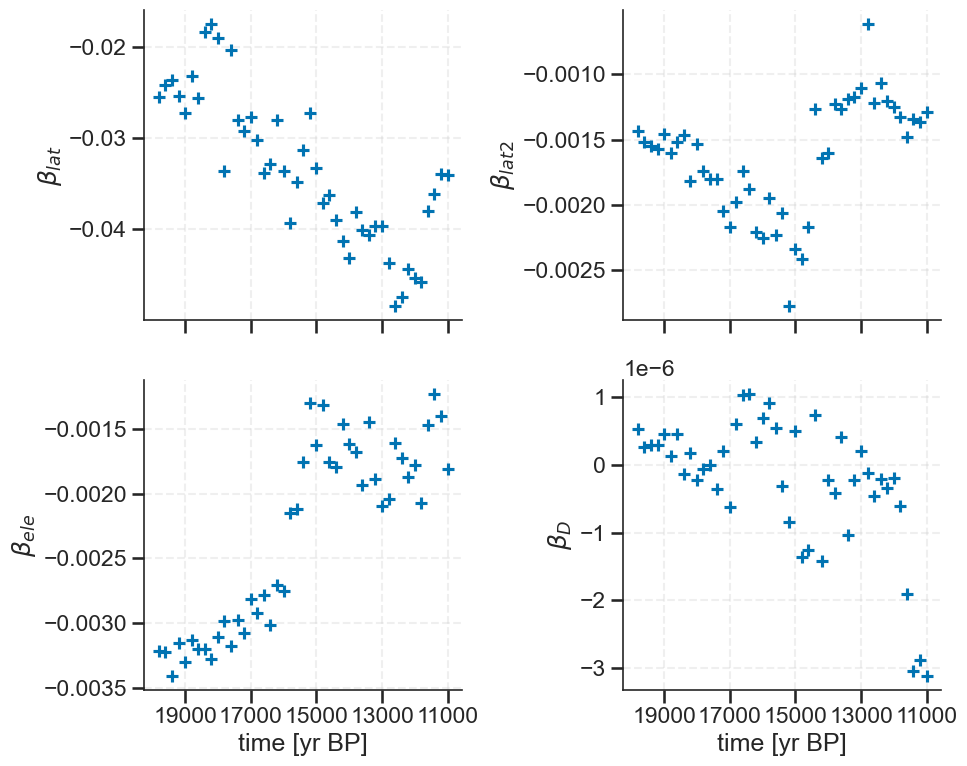

In [ ]:
# from matplotlib.ticker import MaxNLocator

# fig,axes = plt.subplots(2,2,sharex=True,figsize=(10,8))
# for i,pred in enumerate(['lat','lat2','ele','D']):
#     ax = axes[i//2,i%2]
#     ax.scatter(result_df.loc[result_df.name==pred,'time'].values,result_df.loc[result_df.name==pred,'beta'].values,marker='+',label=pred)
#     ax.set_ylabel(rf'$\beta_{{{pred}}}$')
#     ax.grid(linestyle='--',alpha=0.3)

# axes[1,1].set_xlabel('time [yr BP]')
# axes[1,0].set_xlabel('time [yr BP]')
# sns.despine()
# axes[0,0].invert_xaxis()

# axes[0,0].xaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.tight_layout()
# plt.savefig('../output/trendmodel_coefficients_sisal.png',dpi=500)
# plt.show()

#### Investigation of variogram parameters

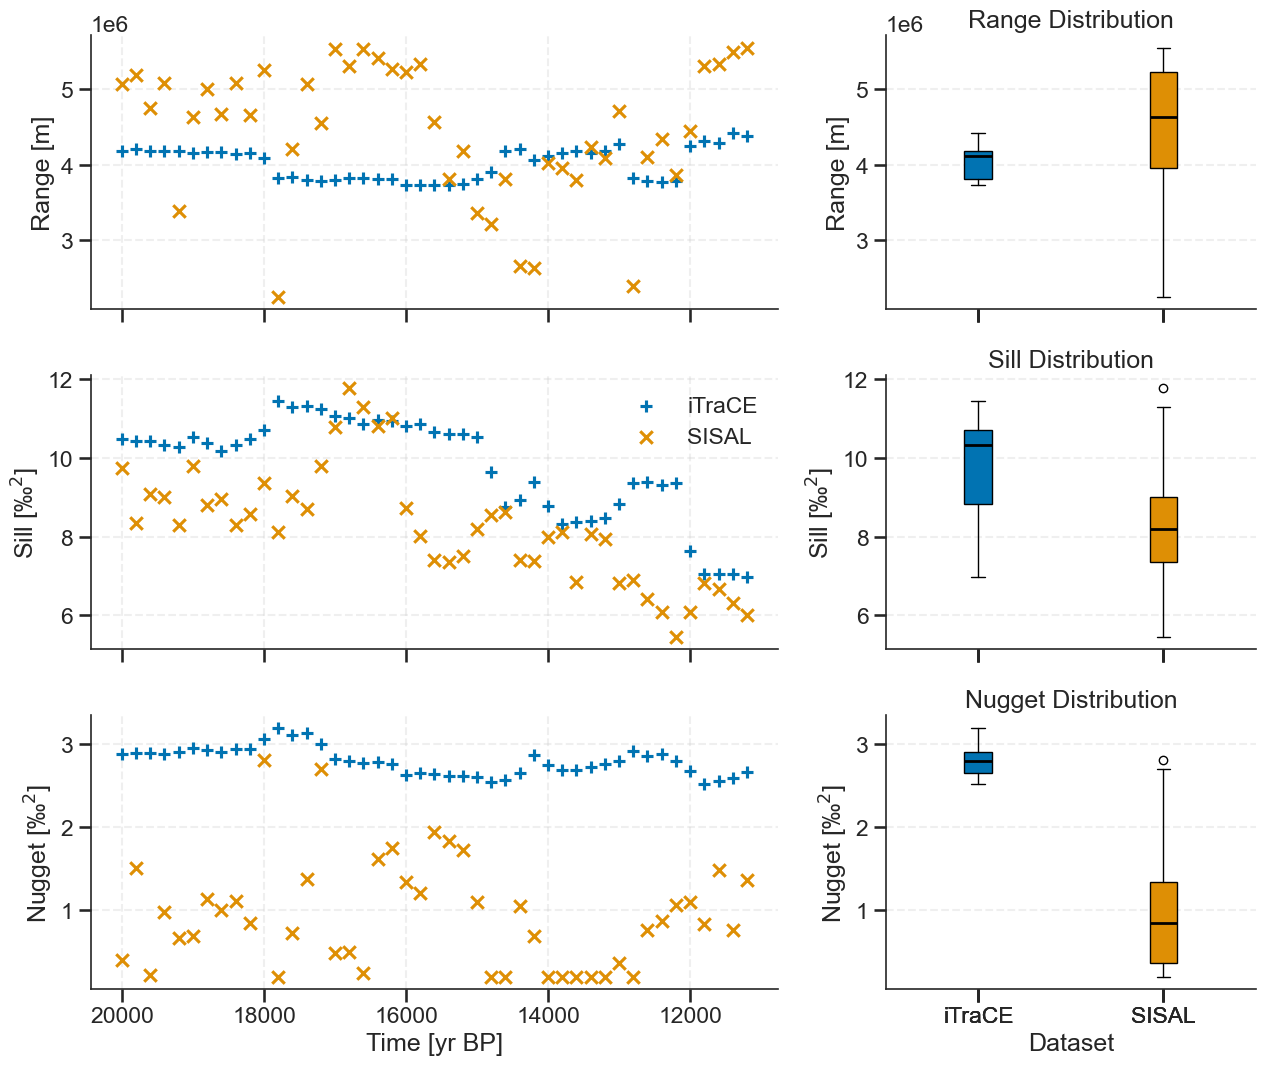

In [3]:
fig, axes = plt.subplots(3,2,figsize=(13,11),sharex='col',gridspec_kw={'width_ratios': [0.65, 0.35]})

# Left column: Scatter plots over time
axes[0,0].scatter(vario_df['time'].values,vario_df['range'].values,marker='+',label='iTraCE')
axes[0,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['range'].values,marker='x',label='SISAL')
axes[0,0].set_ylabel('Range [m]')
axes[1,0].scatter(vario_df['time'].values,vario_df['sill'].values,marker='+',label='iTraCE')
axes[1,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['sill'].values,marker='x',label='SISAL')
axes[1,0].set_ylabel(r'Sill [‰$^2$]')
axes[2,0].scatter(vario_df['time'].values,vario_df['nugget'].values,marker='+',label='iTraCE')
axes[2,0].scatter(vario_sisal_df['time'].values,vario_sisal_df['nugget'].values,marker='x',label='SISAL')
axes[2,0].set_ylabel(r'Nugget [‰$^2$]')
axes[2,0].set_xlabel('Time [yr BP]')
axes[1,0].legend(frameon=False)

# Right column: Boxplots comparing distributions
params_list = ['range', 'sill', 'nugget']
labels_list = ['Range', 'Sill', 'Nugget']
ylabels_lists = [['Range [m]'], [r'Sill [‰$^2$]'], [r'Nugget [‰$^2$]']]
colors = sns.color_palette("colorblind", 2)
for i, (param, label) in enumerate(zip(params_list, labels_list)):
    data_to_plot = [vario_df[param].dropna(), vario_sisal_df[param].dropna()]
    bp = axes[i,1].boxplot(data_to_plot, tick_labels=['iTraCE', 'SISAL'], patch_artist=True)
    
    # Color the boxes to match the scatter plot colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Color the median lines black
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    
    axes[i,1].set_ylabel(ylabels_lists[i][0])
    axes[i,1].grid(axis='y', linestyle='--', alpha=0.3)
    axes[i,1].set_title(f'{label} Distribution')

axes[2,1].set_xlabel('Dataset')

# Apply styling to all subplots
sns.despine(top=True,right=True)
axes[0,0].invert_xaxis()
axes[0,0].grid()
axes[1,0].grid()
axes[2,0].grid()

plt.tight_layout()
# plt.savefig('../output/results_figs/fig_variogram_params_over_time.png',dpi=500)
plt.show()